## Overview of Diabetes Readmission Prediction
Using a dataset representing ten years (1999-2008) of clinical care at 130 US hospitals to determine the leading variables of readmission so that hospitals can start taking corrective action and reduce the 30-day readmission rate.

Python Version: 3.13.12

## Installing and Importing Required Libraries
Along with installing the libraries, install ipykernels

In [115]:
# installing libraries
%pip install seaborn
%pip install missingno
%pip install xgboost
%pip install catboost
%pip install regex
%pip install sklearn
%pip install pandas
%pip install numpy
%pip install imblearn
%pip install lightgbm


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies ... done
  Getting requireme

In [116]:
# importing libraries
import pandas as pd   # data processing, CSV file I/O (e.g. pd.read_csv)
import numpy as np   # linear algebra
import matplotlib.pyplot as plt  #graphs and plots
import seaborn as sns   #data visualizations 
import csv # Some extra functionalities for csv  files - reading it as a dictionary
from lightgbm import LGBMClassifier #sklearn is for machine learning and statistical modeling including classification, regression, clustering and dimensionality reduction 

from sklearn.model_selection import train_test_split, cross_validate   #break up dataset into train and test sets

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler


# importing python library for working with missing data
import missingno as msno
# To install missingno use: !pip install missingno
import re    # This library is used to perform regex pattern matching

# import various functions from sklearn
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import GradientBoostingClassifier
from catboost import CatBoostClassifier
import xgboost as xgb
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, classification_report, make_scorer
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split

from sklearn.model_selection import KFold,cross_val_score, RepeatedStratifiedKFold,StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import OneHotEncoder,StandardScaler,PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer,SimpleImputer
from sklearn.compose import make_column_transformer
from imblearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, balanced_accuracy_score,precision_score, recall_score, roc_auc_score, ConfusionMatrixDisplay, classification_report, RocCurveDisplay, f1_score

import plotly 
import plotly.express as px
import plotly.graph_objs as go
import plotly.offline as py
from plotly.offline import iplot
from plotly.subplots import make_subplots
import plotly.figure_factory as ff

import warnings
warnings.filterwarnings("ignore")

## Loading in Diabetes Data CSV

In [117]:
diabetes = pd.read_csv('UCI_diabetes/diabetic_data.csv')
diabetes.head(5)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [118]:
diabetes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

## Cleaning Diabetes Data CSV

### Deleting Columns that are Mostly Empty

#### Missing Data Overview
First, get an overview of the data we are working with using msno.bar

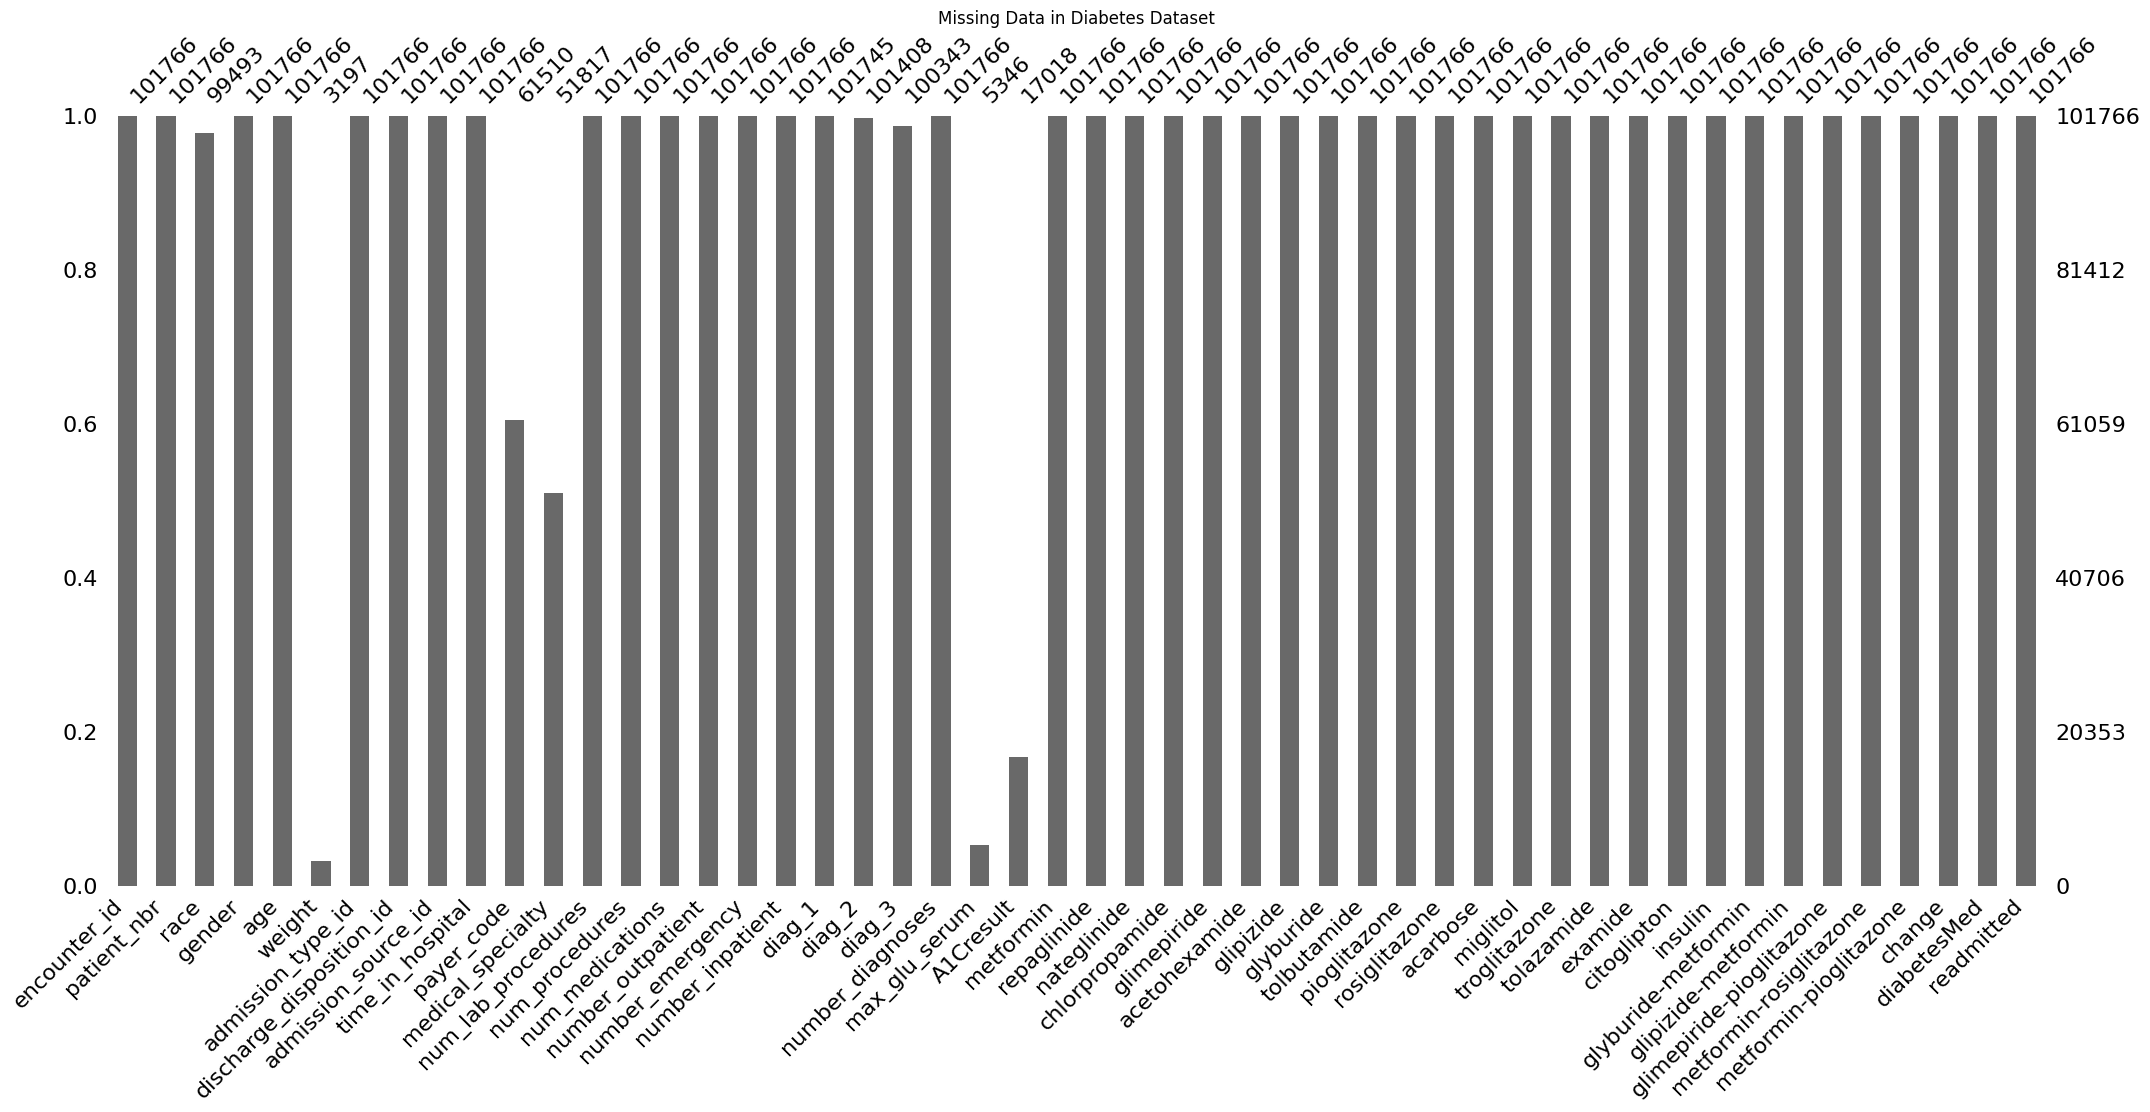

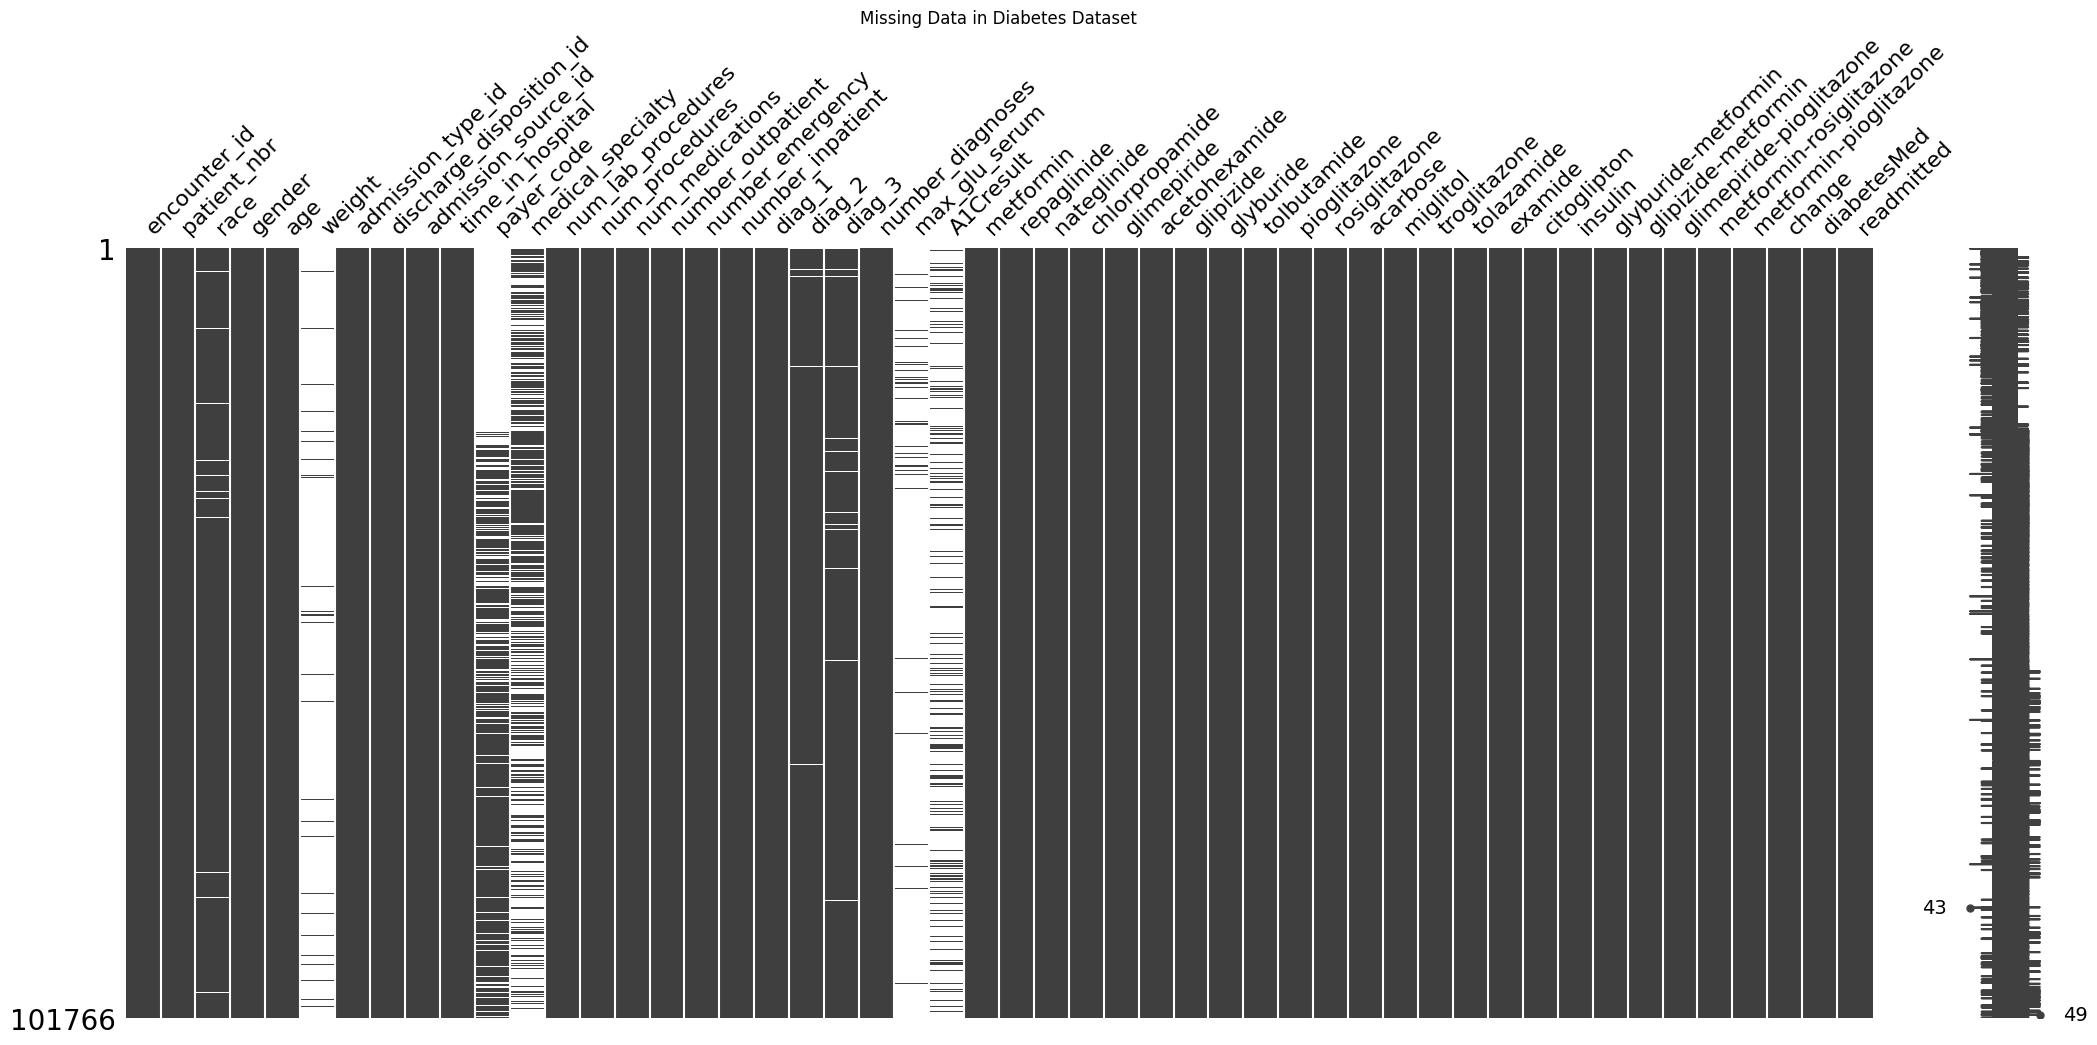

,missing_count,missing_percent
weight,98569,0.968585
max_glu_serum,96420,0.947468
A1Cresult,84748,0.832773
medical_specialty,49949,0.490822
payer_code,40256,0.395574
race,2273,0.022336
diag_3,1423,0.013983
diag_2,358,0.003518
diag_1,21,0.000206
encounter_id,0,0.000000


In [119]:
# The csv files has a lot of "?" which are actually missing values. We will replace them with np.nan for better handling of missing data.
diabetes.replace('?', np.nan, inplace=True)

# missing data bargraph and matrix
msno.bar(diabetes)
plt.title('Missing Data in Diabetes Dataset')
plt.show()
msno.matrix(diabetes)
plt.title('Missing Data in Diabetes Dataset')
plt.show()

# missing data percentage and count
def missing(diabetes):
    missing_count = diabetes.isnull().sum().sort_values(ascending=False)
    missing_percent = (diabetes.isnull().sum() / diabetes.isnull().count()).sort_values(ascending=False)
    missing_table = pd.concat([missing_count, missing_percent], axis=1, keys=['missing_count', 'missing_percent'])
    return missing_table

missing(diabetes)


We identified the following with missing data:
|Columns     | Missing Percentage|
|------------------|------------|
|weight            |   96.8585%|
|max_glu_serum	    |   94.7468%|
|A1Cresult         |   83.2773%|
|medical_specialty |	49.0822%|
|payer_code    	|   39.5574%|
|race	    	    |   02.2336%|
|diag_3		    |   01.3983%|
|diag_2		    |   00.3518%|
|diag_1            |   00.0206%|



We decided to remove columns **weight, max_glu_serum, A1Cresults** because of the massive amount of NaN values. Furthermore, we believe that leaving them in to train the ML model would lead to bias.  


For **medical_specialty**, we will keep it because it can be a strong clinical predictor. To fix the missing values, we will put the NaN values as "Unknown" and treat that as its own category.

For **payer_code**, will drop now, and will retest later on as an add-on:
- Baseline model: drop the column because there is roughly 40% missing data. 
- Comparsion model: missing value as unknown. Then compare the 2 using cross-validation on recall, F1, and AUROC for 30-day readmission. We will keep it if the version does not improve performance in a stable way.

For **race**, we are going to:
- baseline model: drop the 2% missing rows
- comparsion model: add missing values as "unknown"

Since **diag1-3** are ICD-9 codes, mode imputation is a bad idea. It would artificially inflate the apparent prevalence of certain codes. Instead, we can replace the missing values "?", with "Unknown". 


We will also remove **encounter_id** and **patient_nbr** because these columns are identifiers and not necessary to train the model.

## Cleaning Data for the Baseline Model (no payer_code)

### Removing unnecessary/heavily missing columns 

We will create our first basic model with no payer_code. We will make an additional model later on to compare a model with/without payer_code. We will be removing **encounter_id, patient_nbr, weight, max_glu_serum, A1Cresult**, **and payer_code**.

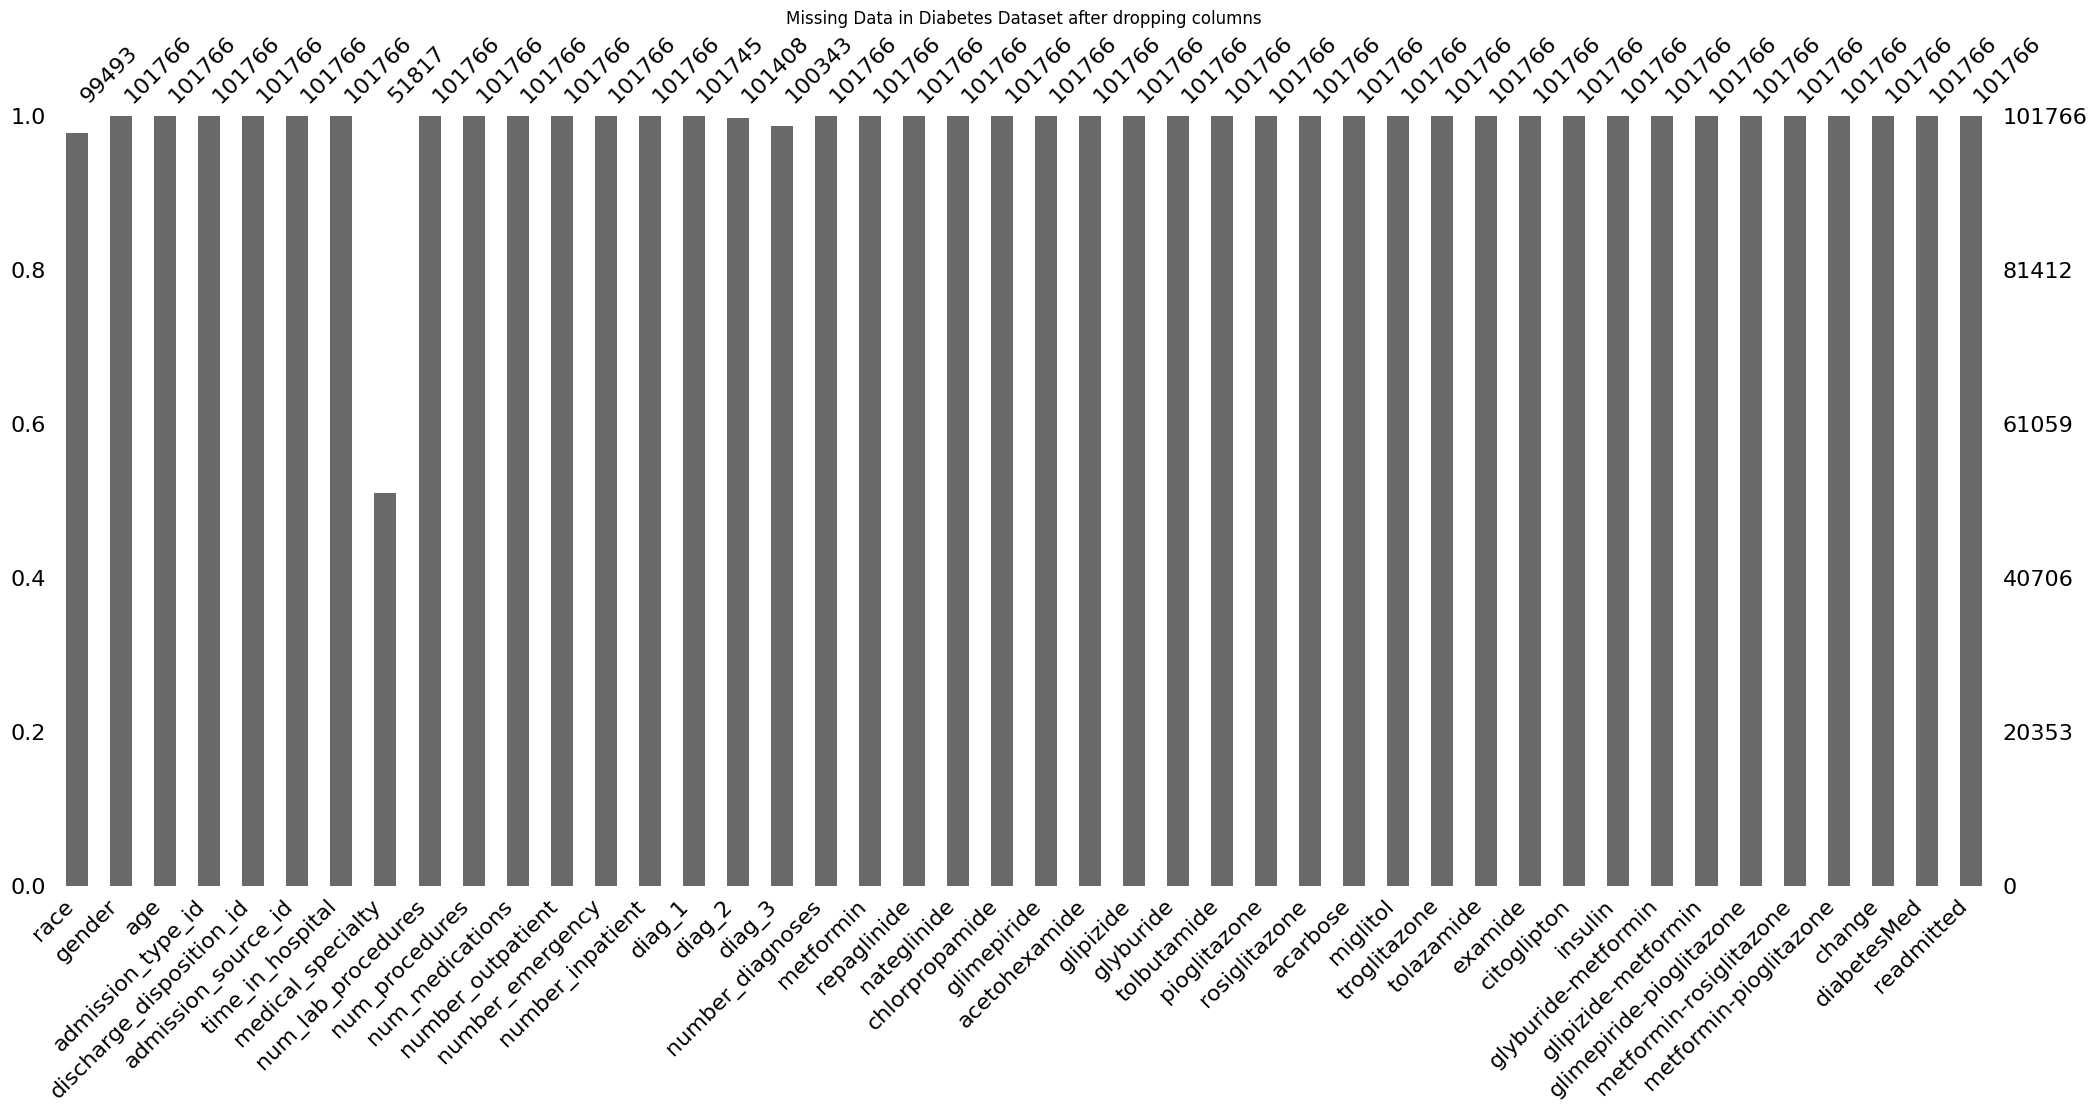

In [120]:
diabetes = diabetes.drop(columns=['weight', 'payer_code', 'encounter_id', 'patient_nbr', 'max_glu_serum', 'A1Cresult'])
diabetes.head()
msno.bar(diabetes)
plt.title('Missing Data in Diabetes Dataset after dropping columns')   
plt.show()


### Adding "Unknown" column to medical_specialty, diag1-3, race
We want to keep all the rows because we believe these rows still provide crucial data. We want to avoid injecting fake labels in the baseline model. 

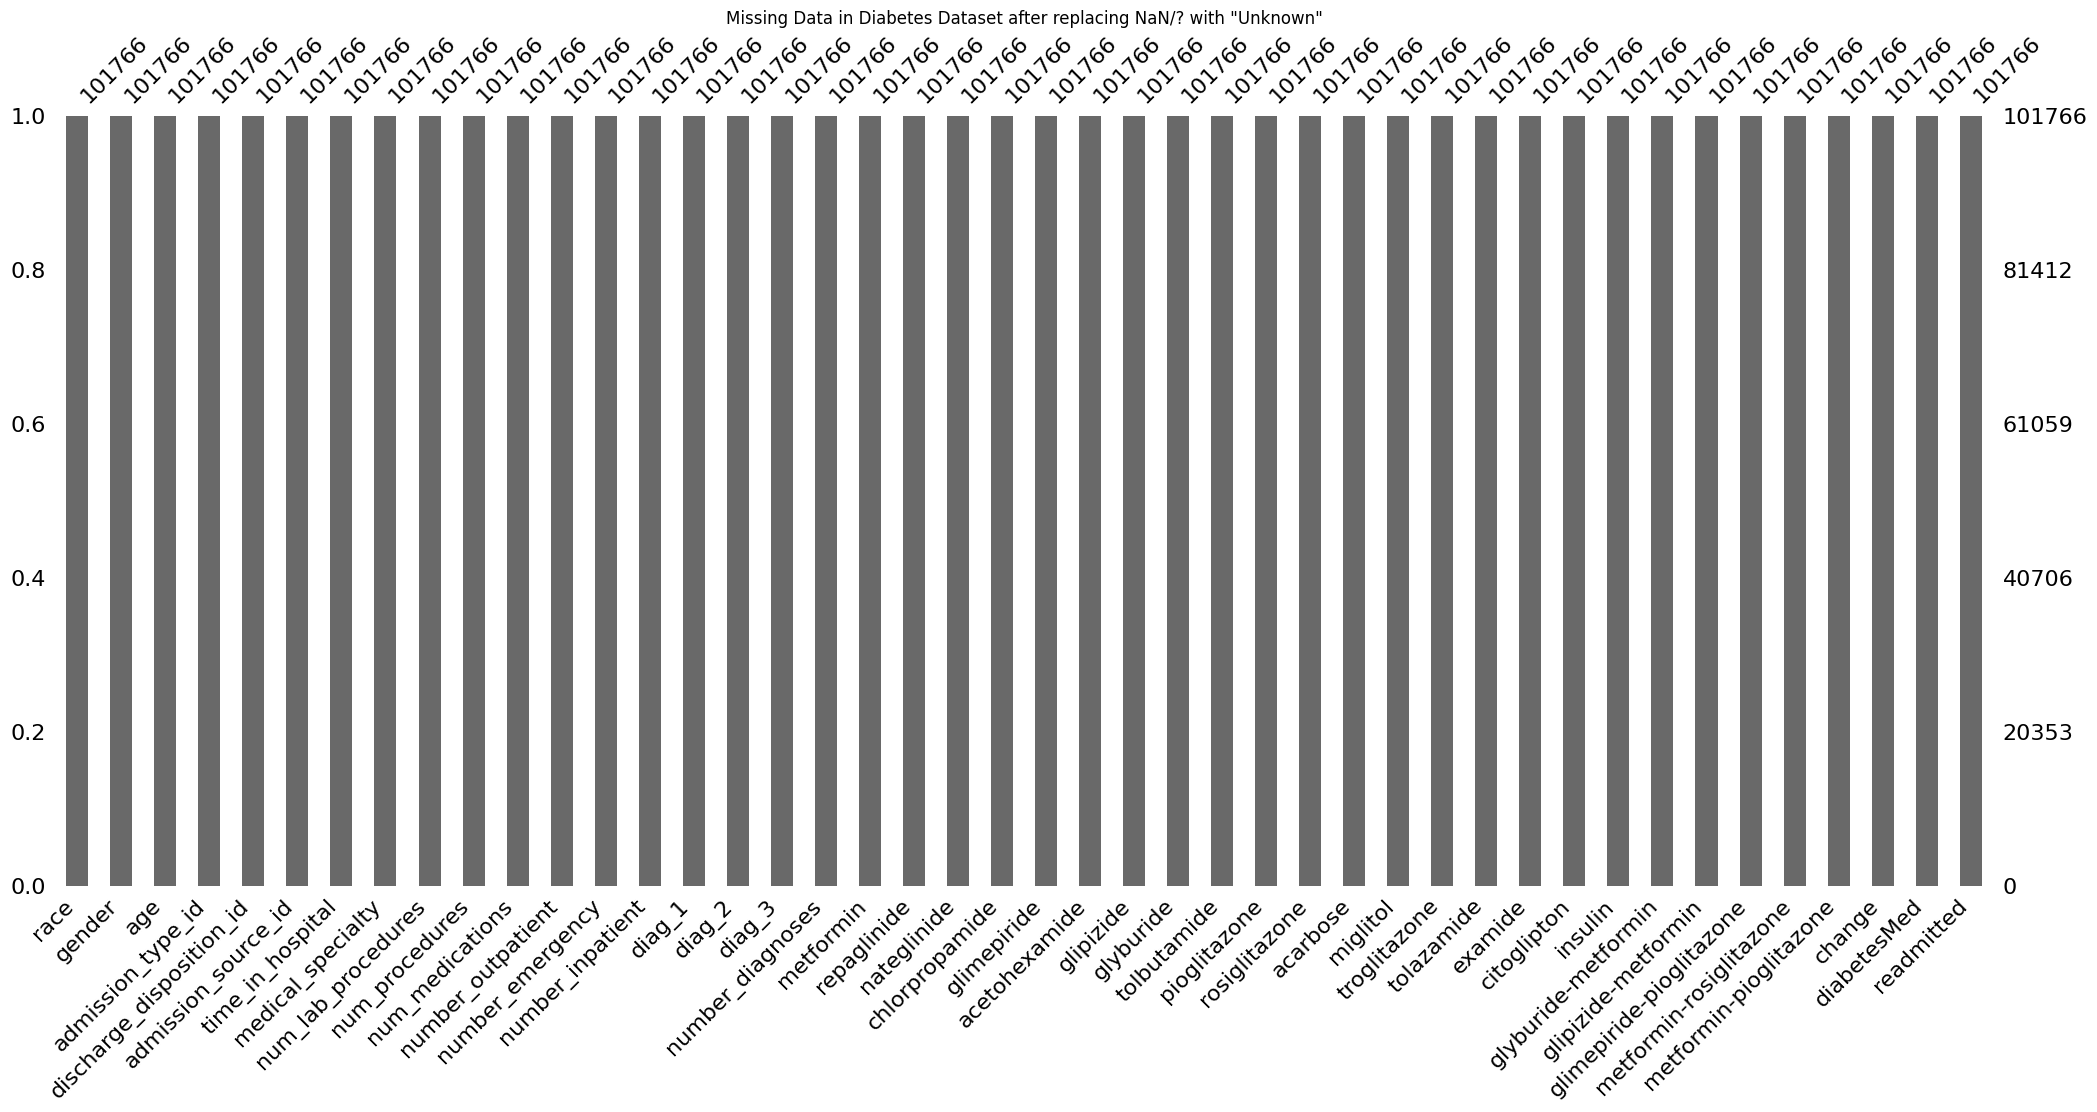

,missing_count,missing_percent
race,0,0.0
gender,0,0.0
glipizide,0,0.0
glyburide,0,0.0
tolbutamide,0,0.0
pioglitazone,0,0.0
rosiglitazone,0,0.0
acarbose,0,0.0
miglitol,0,0.0
troglitazone,0,0.0


In [121]:
# Replace both NaN and '?' with "Unknown" for selected categorical columns
cols_to_replace = ['medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'race']

diabetes[cols_to_replace] = (
    diabetes[cols_to_replace]
    .replace(r'^\s*\?\s*$', np.nan, regex=True)
    .fillna('Unknown')
)

msno.bar(diabetes)
plt.title('Missing Data in Diabetes Dataset after replacing NaN/? with "Unknown"')
plt.show()

# missing data percentage and count
def missing(diabetes):
    missing_count = diabetes.isnull().sum().sort_values(ascending=False)
    missing_percent = (diabetes.isnull().sum() / diabetes.isnull().count()).sort_values(ascending=False)
    missing_table = pd.concat([missing_count, missing_percent], axis=1, keys=['missing_count', 'missing_percent'])
    return missing_table

missing(diabetes)

### Converting Categorical Features into Numeric Features
We are going to convert columns like race and gender into numerical columns instead by separating them and have 1 as yes and 0 as no. 

However, there are certain columns that are more difficult, so we will personally convert those into numerical features. They are the age, and group dig1-3.

In [122]:
diabetes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 44 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   race                      101766 non-null  object
 1   gender                    101766 non-null  object
 2   age                       101766 non-null  object
 3   admission_type_id         101766 non-null  int64 
 4   discharge_disposition_id  101766 non-null  int64 
 5   admission_source_id       101766 non-null  int64 
 6   time_in_hospital          101766 non-null  int64 
 7   medical_specialty         101766 non-null  object
 8   num_lab_procedures        101766 non-null  int64 
 9   num_procedures            101766 non-null  int64 
 10  num_medications           101766 non-null  int64 
 11  number_outpatient         101766 non-null  int64 
 12  number_emergency          101766 non-null  int64 
 13  number_inpatient          101766 non-null  int64 
 14  diag

#### Grouping diag1-3 into ICD-9 Codes
Diag1-3 have hundreds of unique values so one-hot encoding would explode the features space. To prevent this, we will group these codes into 9 clinical buckets based on ICD-9 code ranges.

In [123]:
# Robust ICD-9 grouping that is safe to re-run
grouped_labels = {
    'Unknown', 'Supplementary', 'External_Causes', 'Infectious_Parasitic',
    'Neoplasms', 'Endocrine_Metabolic', 'Blood_Disorders', 'Mental_Disorders',
    'Nervous_System', 'Circulatory_System', 'Respiratory_System', 'Digestive_System',
    'Genitourinary_System', 'Pregnancy_Childbirth', 'Skin', 'Musculoskeletal_System',
    'Congenital_Anomalies', 'Perinatal', 'Symptoms_Signs', 'Injury_Poisoning', 'Other'
}

def group_icd(code):
    # Handle missing-like values first
    if pd.isna(code):
        return 'Unknown'

    s = str(code).strip()
    if s in grouped_labels:
        return s
    if s in {'?', ''}:
        return 'Unknown'

    s_upper = s.upper()
    if s_upper.startswith('V'):
        return 'Supplementary'
    if s_upper.startswith('E') and len(s_upper) > 1 and s_upper[1].isdigit():
        return 'External_Causes'

    try:
        num = float(s)
        if 1 <= num <= 139:
            return 'Infectious_Parasitic'
        elif 140 <= num <= 239:
            return 'Neoplasms'
        elif 240 <= num <= 279:
            return 'Endocrine_Metabolic'
        elif 280 <= num <= 289:
            return 'Blood_Disorders'
        elif 290 <= num <= 319:
            return 'Mental_Disorders'
        elif 320 <= num <= 389:
            return 'Nervous_System'
        elif 390 <= num <= 459:
            return 'Circulatory_System'
        elif 460 <= num <= 519:
            return 'Respiratory_System'
        elif 520 <= num <= 579:
            return 'Digestive_System'
        elif 580 <= num <= 629:
            return 'Genitourinary_System'
        elif 630 <= num <= 679:
            return 'Pregnancy_Childbirth'
        elif 680 <= num <= 709:
            return 'Skin'
        elif 710 <= num <= 739:
            return 'Musculoskeletal_System'
        elif 740 <= num <= 759:
            return 'Congenital_Anomalies'
        elif 760 <= num <= 779:
            return 'Perinatal'
        elif 780 <= num <= 799:
            return 'Symptoms_Signs'
        elif 800 <= num <= 999:
            return 'Injury_Poisoning'
        else:
            return 'Other'
    except Exception:
        return 'Other'

for col in ['diag_1', 'diag_2', 'diag_3']:
    diabetes[col] = diabetes[col].apply(group_icd)

print('diag1-3 grouped categories:')
print(diabetes[['diag_1', 'diag_2', 'diag_3']].head(10))

diag1-3 grouped categories:
                 diag_1               diag_2                diag_3
0   Endocrine_Metabolic              Unknown               Unknown
1   Endocrine_Metabolic  Endocrine_Metabolic   Endocrine_Metabolic
2  Pregnancy_Childbirth  Endocrine_Metabolic         Supplementary
3  Infectious_Parasitic  Endocrine_Metabolic    Circulatory_System
4             Neoplasms            Neoplasms   Endocrine_Metabolic
5    Circulatory_System   Circulatory_System   Endocrine_Metabolic
6    Circulatory_System   Circulatory_System         Supplementary
7    Circulatory_System   Respiratory_System   Endocrine_Metabolic
8    Circulatory_System   Circulatory_System  Infectious_Parasitic
9    Circulatory_System            Neoplasms    Respiratory_System


#### OrdinalEncoder the age column

Because age is in a sequential relationship, we cannot onehotendcoder this feature. 

In [124]:
# ordinalencode for age column
age_mapping = {
    '[0-10)': 0,
    '[10-20)': 1,
    '[20-30)': 2,
    '[30-40)': 3,
    '[40-50)': 4,
    '[50-60)': 5,
    '[60-70)': 6,
    '[70-80)': 7,
    '[80-90)': 8,
    '[90-100)': 9
}
diabetes['age'] = diabetes['age'].map(age_mapping)
diabetes.head(10)

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,0,6,25,1,1,Pediatrics-Endocrinology,41,0,...,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,1,1,1,7,3,Unknown,59,0,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,2,1,1,7,2,Unknown,11,5,...,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,3,1,1,7,2,Unknown,44,1,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,4,1,1,7,1,Unknown,51,0,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
5,Caucasian,Male,5,2,1,2,3,Unknown,31,6,...,No,Steady,No,No,No,No,No,No,Yes,>30
6,Caucasian,Male,6,3,1,2,4,Unknown,70,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
7,Caucasian,Male,7,1,1,7,5,Unknown,73,0,...,No,No,No,No,No,No,No,No,Yes,>30
8,Caucasian,Female,8,2,1,4,13,Unknown,68,2,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
9,Caucasian,Female,9,3,3,4,12,InternalMedicine,33,3,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


#### Clean readmission column so only <30 day remission is 0 while >30 day readmission and no readmission is 0

The project only is asking for <30 day readmission prediction. All other values should become 0 (>30 day readmission and no readmission)

In [125]:
# Keep this transformation rerun-safe and deterministic
readmit_map = {
    '<30': 1,
    '>30': 0,
    'NO': 0,
    1: 1,
    0: 0,
    '1': 1,
    '0': 0,
}

diabetes['readmitted'] = diabetes['readmitted'].map(readmit_map)
diabetes.head(15)

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,0,6,25,1,1,Pediatrics-Endocrinology,41,0,...,No,No,No,No,No,No,No,No,No,0
1,Caucasian,Female,1,1,1,7,3,Unknown,59,0,...,No,Up,No,No,No,No,No,Ch,Yes,0
2,AfricanAmerican,Female,2,1,1,7,2,Unknown,11,5,...,No,No,No,No,No,No,No,No,Yes,0
3,Caucasian,Male,3,1,1,7,2,Unknown,44,1,...,No,Up,No,No,No,No,No,Ch,Yes,0
4,Caucasian,Male,4,1,1,7,1,Unknown,51,0,...,No,Steady,No,No,No,No,No,Ch,Yes,0
5,Caucasian,Male,5,2,1,2,3,Unknown,31,6,...,No,Steady,No,No,No,No,No,No,Yes,0
6,Caucasian,Male,6,3,1,2,4,Unknown,70,1,...,No,Steady,No,No,No,No,No,Ch,Yes,0
7,Caucasian,Male,7,1,1,7,5,Unknown,73,0,...,No,No,No,No,No,No,No,No,Yes,0
8,Caucasian,Female,8,2,1,4,13,Unknown,68,2,...,No,Steady,No,No,No,No,No,Ch,Yes,0
9,Caucasian,Female,9,3,3,4,12,InternalMedicine,33,3,...,No,Steady,No,No,No,No,No,Ch,Yes,0


In [126]:
# Safety check: mapping must produce only 0/1 and no nulls
assert diabetes["readmitted"].isna().sum() == 0, "Unmapped readmitted values found."
assert set(diabetes["readmitted"].unique()) <= {0, 1}, "Target must be binary 0/1."

print("Nulls in readmitted:", diabetes["readmitted"].isna().sum())
print("Unique mapped values:", sorted(diabetes["readmitted"].dropna().unique()))

Nulls in readmitted: 0
Unique mapped values: [np.int64(0), np.int64(1)]


#### Split into train/test before scaling

In [127]:
# Stratified 70/15/15 split (train/valid/test)
from sklearn.model_selection import train_test_split

# 1) 70% train, 30% temp
train_df, temp_df = train_test_split(
    diabetes,
    test_size=0.30,
    random_state=42,
    stratify=diabetes["readmitted"]
)

# 2) Split temp into 15% valid, 15% test
valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["readmitted"]
)

# Clean indices
train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# Quick check of class balance
print("Row counts:")
print(f"train: {len(train_df)}  valid: {len(valid_df)}  test: {len(test_df)}")

print("\nClass ratio (readmitted=1) by split:")
print("total :", diabetes["readmitted"].mean())
print("train :", train_df["readmitted"].mean())
print("valid :", valid_df["readmitted"].mean())
print("test  :", test_df["readmitted"].mean())

Row counts:
train: 71236  valid: 15265  test: 15265

Class ratio (readmitted=1) by split:
total : 0.11159915885462728
train : 0.11160087596159245
valid : 0.11162790697674418
test  : 0.11156239764166394


In [128]:
# Guardrails: fail fast if split variables are not defined correctly
required = ["train_df", "valid_df", "test_df", "temp_df"]
for name in required:
    assert name in globals(), f"{name} is missing. Re-run split cell."

assert len(train_df) > 0 and len(valid_df) > 0 and len(test_df) > 0, "Empty split detected."
assert set(train_df.columns) == set(valid_df.columns) == set(test_df.columns), "Column mismatch across splits."

# Optional: strict 70/15/15 sanity check within tolerance
n = len(diabetes)
train_ratio = len(train_df) / n
valid_ratio = len(valid_df) / n
test_ratio = len(test_df) / n
print("\nSplit ratios:", round(train_ratio, 3), round(valid_ratio, 3), round(test_ratio, 3))


Split ratios: 0.7 0.15 0.15


#### Define the y-value and separate x and y values
We are going to separate the y_value from the rest of the database to hide the solution from the model

In [129]:
target_col = 'readmitted'

x_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]

x_valid = valid_df.drop(columns=[target_col])
y_valid = valid_df[target_col]

x_test = test_df.drop(columns=[target_col])
y_test = test_df[target_col]

#### OneHotEncoder the nominal columns

In [130]:
# onehotencode for nominal categorical columns

nominal_cols = [
    'race',
    'gender',
    'medical_specialty',
    'diag_1',
    'diag_2',
    'diag_3',
    'admission_type_id',
    'discharge_disposition_id',
    'admission_source_id',
    'metformin',
    'repaglinide',
    'nateglinide',
    'chlorpropamide',
    'glimepiride',
    'acetohexamide',
    'glipizide',
    'glyburide',
    'tolbutamide',
    'pioglitazone',
    'rosiglitazone',
    'acarbose',
    'miglitol',
    'troglitazone',
    'tolazamide',
    'examide',
    'citoglipton',
    'insulin',
    'glyburide-metformin',
    'glipizide-metformin',
    'glimepiride-pioglitazone',
    'metformin-rosiglitazone',
    'metformin-pioglitazone',
    'change',
    'diabetesMed'
]

# Fit encoding structure from train split, then align valid/test to train columns
x_train = pd.get_dummies(x_train, columns=nominal_cols, drop_first=False)
x_valid = pd.get_dummies(x_valid, columns=nominal_cols, drop_first=False)
x_test = pd.get_dummies(x_test, columns=nominal_cols, drop_first=False)

# Ensure identical feature columns across splits
x_valid = x_valid.reindex(columns=x_train.columns, fill_value=0)
x_test = x_test.reindex(columns=x_train.columns, fill_value=0)

print('Encoded shapes:')
print('x_train:', x_train.shape)
print('x_valid:', x_valid.shape)
print('x_test :', x_test.shape)


Encoded shapes:
x_train: (71236, 268)
x_valid: (15265, 268)
x_test : (15265, 268)


### Training Baseline Model

#### Scale the continuous column type through StandardScaler only x_train data

The continuous columns in this data set are: 

[time_in_hospital, num_lab_procedures, num_procedures, num_medications, number_outpatient,number_emergency, number_inpatient, number_diagnoses]

We need to scale these numbers to standardize these continuous values.

In [131]:
# standardscaler for continuous features
scaler = StandardScaler()
continuous_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
                   'num_medications', 'number_outpatient', 'number_emergency',
                   'number_inpatient', 'number_diagnoses']


x_train[continuous_cols] = scaler.fit_transform(x_train[continuous_cols])
x_valid[continuous_cols] = scaler.transform(x_valid[continuous_cols])
x_test[continuous_cols] = scaler.transform(x_test[continuous_cols])

x_train.head()


,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,race_AfricanAmerican,...,glimepiride-pioglitazone_No,glimepiride-pioglitazone_Steady,metformin-rosiglitazone_No,metformin-rosiglitazone_Steady,metformin-pioglitazone_No,metformin-pioglitazone_Steady,change_Ch,change_No,diabetesMed_No,diabetesMed_Yes
0,7,0.204435,-0.055340,-0.785627,-0.863428,-0.291334,-0.202245,-0.501231,-0.218993,False,...,True,False,True,False,True,False,False,True,True,False
1,6,3.219570,-0.462001,0.389120,0.863241,1.289463,-0.202245,1.879202,-1.254142,False,...,True,False,True,False,True,False,True,False,False,True
2,6,-1.135626,-2.139476,0.389120,0.246573,2.079861,-0.202245,-0.501231,0.816155,False,...,True,False,True,False,True,False,False,True,False,True
3,4,-1.135626,-0.157005,0.389120,-0.493427,-0.291334,-0.202245,-0.501231,-0.218993,True,...,True,False,True,False,True,False,False,True,False,True
4,9,-1.135626,-0.766997,2.738614,-0.616761,-0.291334,-0.202245,0.292247,-1.254142,False,...,True,False,True,False,True,False,False,True,False,True


## Baseline Model Testing

#### Treating the Imbalance in the Training Data

We need to balance out the data because >30 day readmission has a massive bias. We will cannot use sub-sampling because there is a major imbalance between 0 and 1 y_values (ratio 8:1). We will train a weighted model on training data + threshold tuning. 

We did not rebalance before the split. If we rebalance the full dataset first, information leaks into validation/test and our metrics look better than reality.

In [132]:
print("Y_value Counts in Training Set:")
print(y_train.value_counts())
print("\n Y_Value Ratio in Training Set:")
print(y_train.value_counts(normalize=True))

Y_value Counts in Training Set:
readmitted
0    63286
1     7950
Name: count, dtype: int64

 Y_Value Ratio in Training Set:
readmitted
0    0.888399
1    0.111601
Name: proportion, dtype: float64


In [133]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
x_train_resampled, y_train_resampled = ros.fit_resample(x_train, y_train)

print("Y counts after ROS:")
print(y_train_resampled.value_counts())
print("\nY ratio after ROS:")
print(y_train_resampled.value_counts(normalize=True))

Y counts after ROS:
readmitted
0    63286
1    63286
Name: count, dtype: int64

Y ratio after ROS:
readmitted
0    0.5
1    0.5
Name: proportion, dtype: float64


In [134]:
# Build a combined resampled training dataframe for quick inspection
if isinstance(y_train_resampled, pd.DataFrame):
    y_resampled_series = y_train_resampled.iloc[:, 0]
else:
    y_resampled_series = pd.Series(y_train_resampled, name='readmitted')

train_df_resampled = x_train_resampled.copy()
train_df_resampled['readmitted'] = y_resampled_series.values

# Check class balance after resampling
print("Y_value Counts in Resampled Training Set:")
print(y_resampled_series.value_counts())
print("\nY_value Ratio in Resampled Training Set:")
print(y_resampled_series.value_counts(normalize=True))

Y_value Counts in Resampled Training Set:
readmitted
0    63286
1    63286
Name: count, dtype: int64

Y_value Ratio in Resampled Training Set:
readmitted
0    0.5
1    0.5
Name: proportion, dtype: float64


## Creating and Inputting into Models

In [135]:
def calc_specificity(y_actual, y_pred, thresh):
    # used to calcualte specificity
    return sum((y_pred <thresh) & (y_actual == 0)) /sum (y_actual == 0)

def calc_prevalence(y_actual):
    return (sum(y_actual)/len(y_actual))

def print_report(y_actual, y_pred, thresh = 0.5):
# this function calcualtes all the metrics to assess the machine learning models
# Params:
# y_actual: the true values for the target variables
# y_pred : the predicted value for the target variable
# thresh: the threshold for the probability to be consider a poisitve class. Default value is 0.5, which means if the predicted probability is greater than or equal to 0.5, we will classify it as positive class (1), otherwise negative class (0).
# returns: AUC -ROC curve, accuracy, precision, recall, specificity.
    # AUC is to see how well the model can distinguish betwen the positive and negetive classes. Higher AUC means better performance
    auc = roc_auc_score(y_actual, y_pred)
    # accuracy is the proportion of correct predictions
    accuracy = accuracy_score(y_actual, (y_pred > thresh))
    # recall is the proportion of actual positives that are correctly identified as such
    recall = recall_score(y_actual, (y_pred > thresh))
    # precision is the proportion of positive identifications that are actually correct
    precision = precision_score(y_actual, (y_pred > thresh))
    # specificity is the proportion of actual negatives that are correctly identified as such
    specificity = calc_specificity(y_actual, y_pred, thresh)
    print('AUC:%.3f'%auc)
    print('Accuracy:%.3f'%accuracy)
    print('recall:%.3f'%recall)
    print('precision:%.3f'%precision)
    print('specificity:%.3f'%specificity)
    print('prevalence:%.3f'%calc_prevalence(y_actual))
    print(' ')
    return auc, accuracy, recall, precision, specificity

#### Final Sanity Check Before Model Training

In [136]:
assert x_train.shape[1] == x_valid.shape[1] == x_test.shape[1], "Feature column count mismatch."
assert list(x_train.columns) == list(x_valid.columns) == list(x_test.columns), "Feature column order mismatch."

assert x_train.isna().sum().sum() == 0, "NaNs in x_train."
assert x_valid.isna().sum().sum() == 0, "NaNs in x_valid."
assert x_test.isna().sum().sum() == 0, "NaNs in x_test."

assert y_train.isna().sum() == 0 and y_valid.isna().sum() == 0 and y_test.isna().sum() == 0, "NaNs in target."
assert set(y_train.unique()) <= {0, 1}, "y_train not binary."
assert set(y_valid.unique()) <= {0, 1}, "y_valid not binary."
assert set(y_test.unique()) <= {0, 1}, "y_test not binary."

non_numeric_train = x_train.select_dtypes(exclude=["number"]).columns.tolist()
non_numeric_valid = x_valid.select_dtypes(exclude=["number"]).columns.tolist()
non_numeric_test = x_test.select_dtypes(exclude=["number"]).columns.tolist()

assert len(non_numeric_train) == 0, f"Non-numeric columns in x_train: {non_numeric_train}"
assert len(non_numeric_valid) == 0, f"Non-numeric columns in x_valid: {non_numeric_valid}"
assert len(non_numeric_test) == 0, f"Non-numeric columns in x_test: {non_numeric_test}"

print("All preprocessing sanity checks passed.")

AssertionError: Non-numeric columns in x_train: ['race_AfricanAmerican', 'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Other', 'race_Unknown', 'gender_Female', 'gender_Male', 'gender_Unknown/Invalid', 'medical_specialty_AllergyandImmunology', 'medical_specialty_Anesthesiology', 'medical_specialty_Anesthesiology-Pediatric', 'medical_specialty_Cardiology', 'medical_specialty_Cardiology-Pediatric', 'medical_specialty_DCPTEAM', 'medical_specialty_Dentistry', 'medical_specialty_Emergency/Trauma', 'medical_specialty_Endocrinology', 'medical_specialty_Endocrinology-Metabolism', 'medical_specialty_Family/GeneralPractice', 'medical_specialty_Gastroenterology', 'medical_specialty_Gynecology', 'medical_specialty_Hematology', 'medical_specialty_Hematology/Oncology', 'medical_specialty_Hospitalist', 'medical_specialty_InfectiousDiseases', 'medical_specialty_InternalMedicine', 'medical_specialty_Nephrology', 'medical_specialty_Neurology', 'medical_specialty_Neurophysiology', 'medical_specia

#### Logistic Regression

In [ ]:
lr=LogisticRegression(random_state=42, solver = 'newton-cg', max_iter=1000)
lr.fit(x_train_resampled, y_train_resampled)

y_valid_preds = lr.predict_proba(x_valid)[:,1]

print('Metrics for Validation data for logistic regression:')

lr_valid_auc, lr_valid_accuracy, lr_valid_recall, \
    lr_valid_precision, lr_valid_specificity = print_report(y_valid, y_valid_preds, 0.5)

Metrics for Validation data for logistic regression:
AUC:0.668
Accuracy:0.888
recall:0.022
precision:0.481
specificity:0.997
prevalence:0.112
 
